# **Bioinformatics Project - Computational Drug Discovery [Part 5] Comparing Regressors**

Chanin Nantasenamat

['Data Professor' YouTube channel](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life data science project that you can include in your data science portfolio. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In Part 5, we will be comparing several ML algorithms for build regression models of acetylcholinesterase inhibitors.



## **1. Import libraries**

In [1]:
! pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lazypredict] [lazypredict]


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

## **2. Load the data set**


In [3]:
# Don't need to do this because we already have the file in the repository

#! wget https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv

--2021-01-22 14:57:46--  https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving github.com (github.com)... 192.30.255.112
Connecting to github.com (github.com)|192.30.255.112|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv [following]
--2021-01-22 14:57:46--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.0.133, 151.101.64.133, 151.101.128.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.0.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8363909 (8.0M) [text/plain]
Saving to: ‘acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_f

In [3]:
df = pd.read_csv('acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [15]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

## **3. Data pre-processing**

In [16]:
# Examine X dimension
X.shape

(1571, 881)

In [17]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))    
X = selection.fit_transform(X)
X.shape

(1571, 151)

In [18]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## **4. Compare ML algorithms**

In [24]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
models_train,predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test,predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

In [25]:
# Performance table of the training set (80% subset)
# Model performance is actually stored here, not in predictions_train
models_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
DecisionTreeRegressor,6.939914e-01,7.308100e-01,0.743005,0.076415
ExtraTreeRegressor,6.939914e-01,7.308100e-01,0.743005,0.055923
ExtraTreesRegressor,6.939914e-01,7.308100e-01,0.743005,2.574287
GaussianProcessRegressor,6.939914e-01,7.308100e-01,0.743005,0.438723
RandomForestRegressor,6.374623e-01,6.810824e-01,0.808726,2.128682
BaggingRegressor,6.151047e-01,6.614148e-01,0.833290,0.261168
MLPRegressor,5.545429e-01,6.081397e-01,0.896453,2.466480
HistGradientBoostingRegressor,5.266272e-01,5.835828e-01,0.924116,0.739396
KNeighborsRegressor,3.355552e-01,4.155004e-01,1.094849,0.045231


In [26]:
# Performance table of the test set (20% subset)
# Model performance is actually stored here, not in predictions_test
models_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
GradientBoostingRegressor,-4.913905e-01,2.258068e-01,1.258631e+00,0.685466
NuSVR,-4.929934e-01,2.249748e-01,1.259308e+00,0.392461
SVR,-5.365398e-01,2.023695e-01,1.277541e+00,0.461856
HistGradientBoostingRegressor,-5.874282e-01,1.759529e-01,1.298524e+00,0.727207
RidgeCV,-6.133757e-01,1.624833e-01,1.309093e+00,0.309673
PoissonRegressor,-6.303098e-01,1.536927e-01,1.315946e+00,0.042334
BayesianRidge,-6.322434e-01,1.526889e-01,1.316726e+00,0.469230
RandomForestRegressor,-6.362965e-01,1.505849e-01,1.318360e+00,2.114753
Ridge,-6.371091e-01,1.501631e-01,1.318687e+00,0.030056


## **5. Data visualization of model performance**

[(0.0, 1.0)]

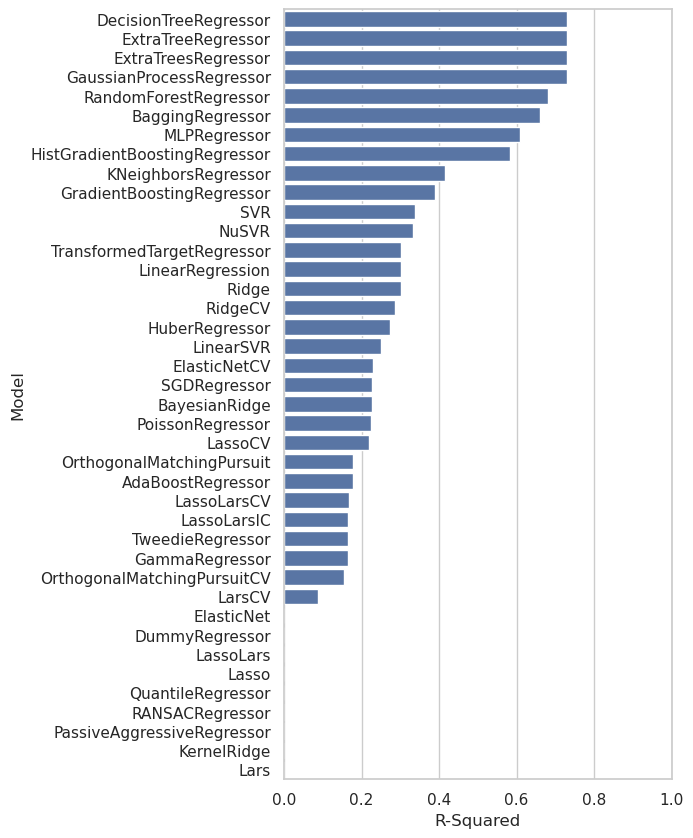

In [28]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="R-Squared", data=models_train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

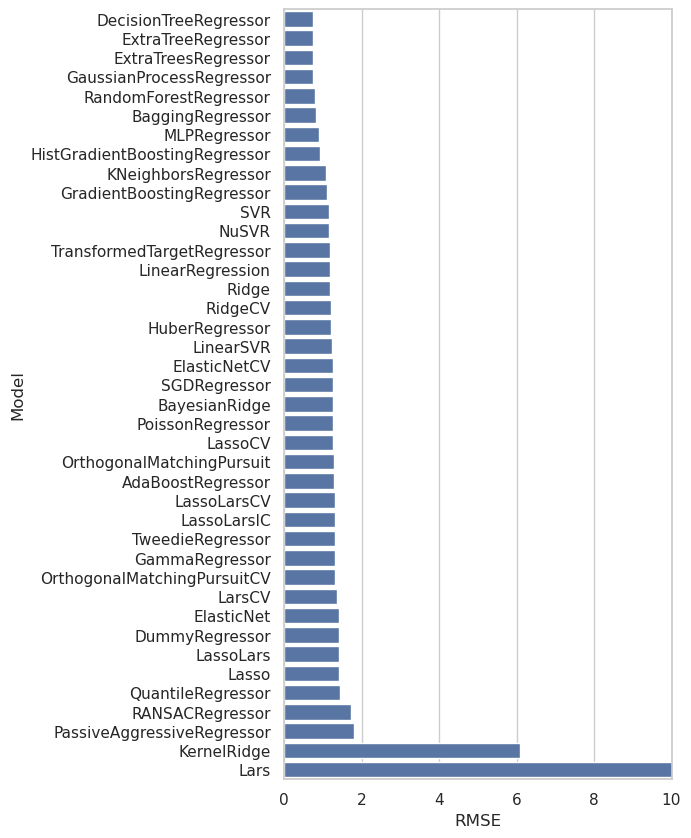

In [29]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="RMSE", data=models_train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

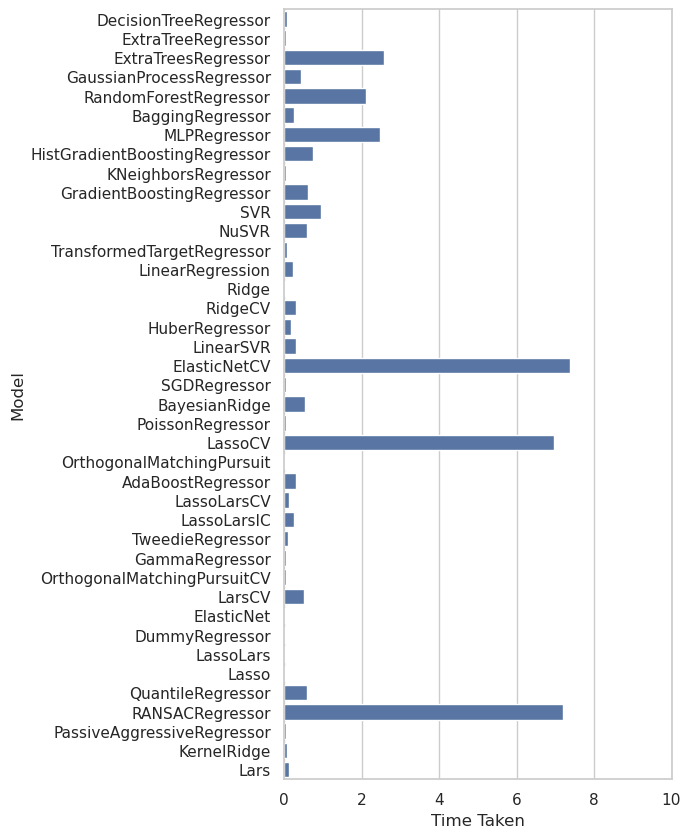

In [30]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="Time Taken", data=models_train)
ax.set(xlim=(0, 10))